# Understanding the Impact of State Level Funding on Student Outcomes
## CS 1090A Final Project
### by Alex Fernand, Moniola, Grace Augustine, and Garland Catlette

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample
from scipy.stats import t

## Exploratory Data Analysis

In [60]:
df = pd.read_excel("data/StateIndicatorsDatabase_2025.xlsx", sheet_name="Data")

# Filtering data for the years 2009 to 2019 to address missingness
df = df[(df["year"] >= 2009) & (df["year"] <= 2019)]
df.head()

/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio,case,citation,ruling,casetype
153,2019,AL,Alabama,1,South,East South Central,0.035605,0.038865,431.6210,686.7686,...,0.197983,0.861250,0.000795,82750.59,125697.30,0.658332,NaN,NaN,NaN,NaN
154,2019,AK,Alaska,2,West,Pacific,0.042915,0.053074,753.8663,1773.2300,...,0.225739,0.853597,0.055628,98056.77,87579.52,1.119631,NaN,NaN,NaN,NaN
155,2019,AZ,Arizona,4,West,Mountain,0.026370,0.029332,325.9877,613.1902,...,0.196911,0.895027,0.306565,101541.70,127656.70,0.795428,NaN,NaN,NaN,NaN
156,2019,AR,Arkansas,5,South,West South Central,0.042158,0.042279,512.3929,779.2733,...,0.214611,0.902905,0.075659,79239.53,120330.90,0.658514,NaN,NaN,NaN,NaN
157,2019,CA,California,6,West,Pacific,0.031838,0.038167,421.1313,749.0176,...,0.164208,0.901418,0.141387,125382.30,209634.50,0.598100,NaN,NaN,NaN,NaN


In [61]:
predictors_of_interest = ["year", "state_name", "region4", "region9", "necm_fundinggap_state", "tchsalary25_30", "tchsalary31_40", "tchsalary41_50", "tchsalary51_60"]
response_var = "necm_outcomegap_state"

#Removed states with missing data for the response variable (Vermont, Alaska, Hawaii)
filtered_df = df[predictors_of_interest + [response_var]].dropna(subset=[response_var]).reset_index(drop=True)
filtered_df.head()

,year,state_name,region4,region9,necm_fundinggap_state,tchsalary25_30,tchsalary31_40,tchsalary41_50,tchsalary51_60,necm_outcomegap_state
0,2019,Alabama,South,East South Central,-5113.8250,22722.28,26305.53,30608.79,34383.88,-0.298386
1,2019,Arizona,West,Mountain,-2852.4060,23866.37,27316.04,31145.49,34346.01,-0.078379
2,2019,Arkansas,South,West South Central,-3977.7690,26109.33,30070.11,33990.20,37660.96,-0.167177
3,2019,California,West,Pacific,-1159.8540,33505.51,39057.78,45146.67,50639.00,-0.137851
4,2019,Colorado,West,Mountain,32.1782,22873.91,26307.92,30430.89,33815.88,0.107602


### Visualizing Collinearity

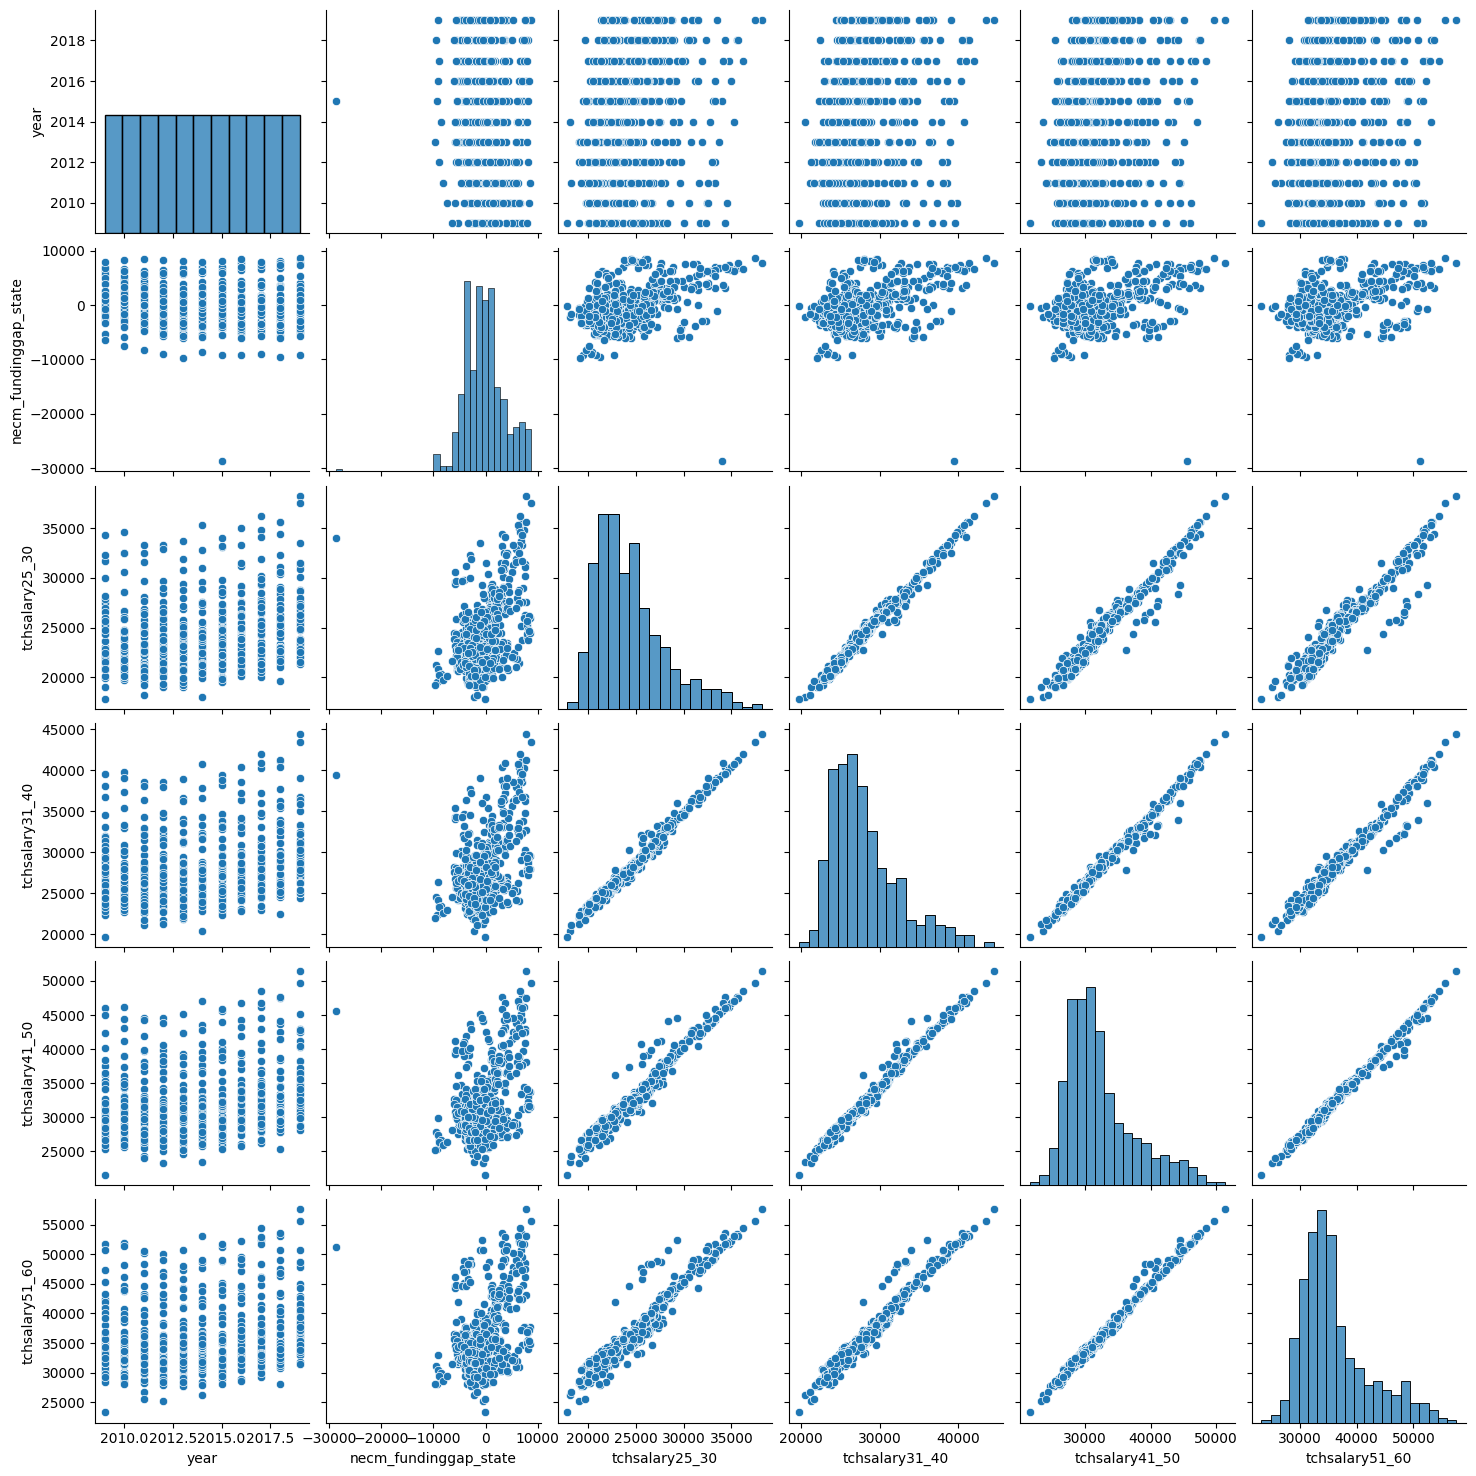

In [62]:
sns.pairplot(filtered_df[predictors_of_interest])
plt.show()

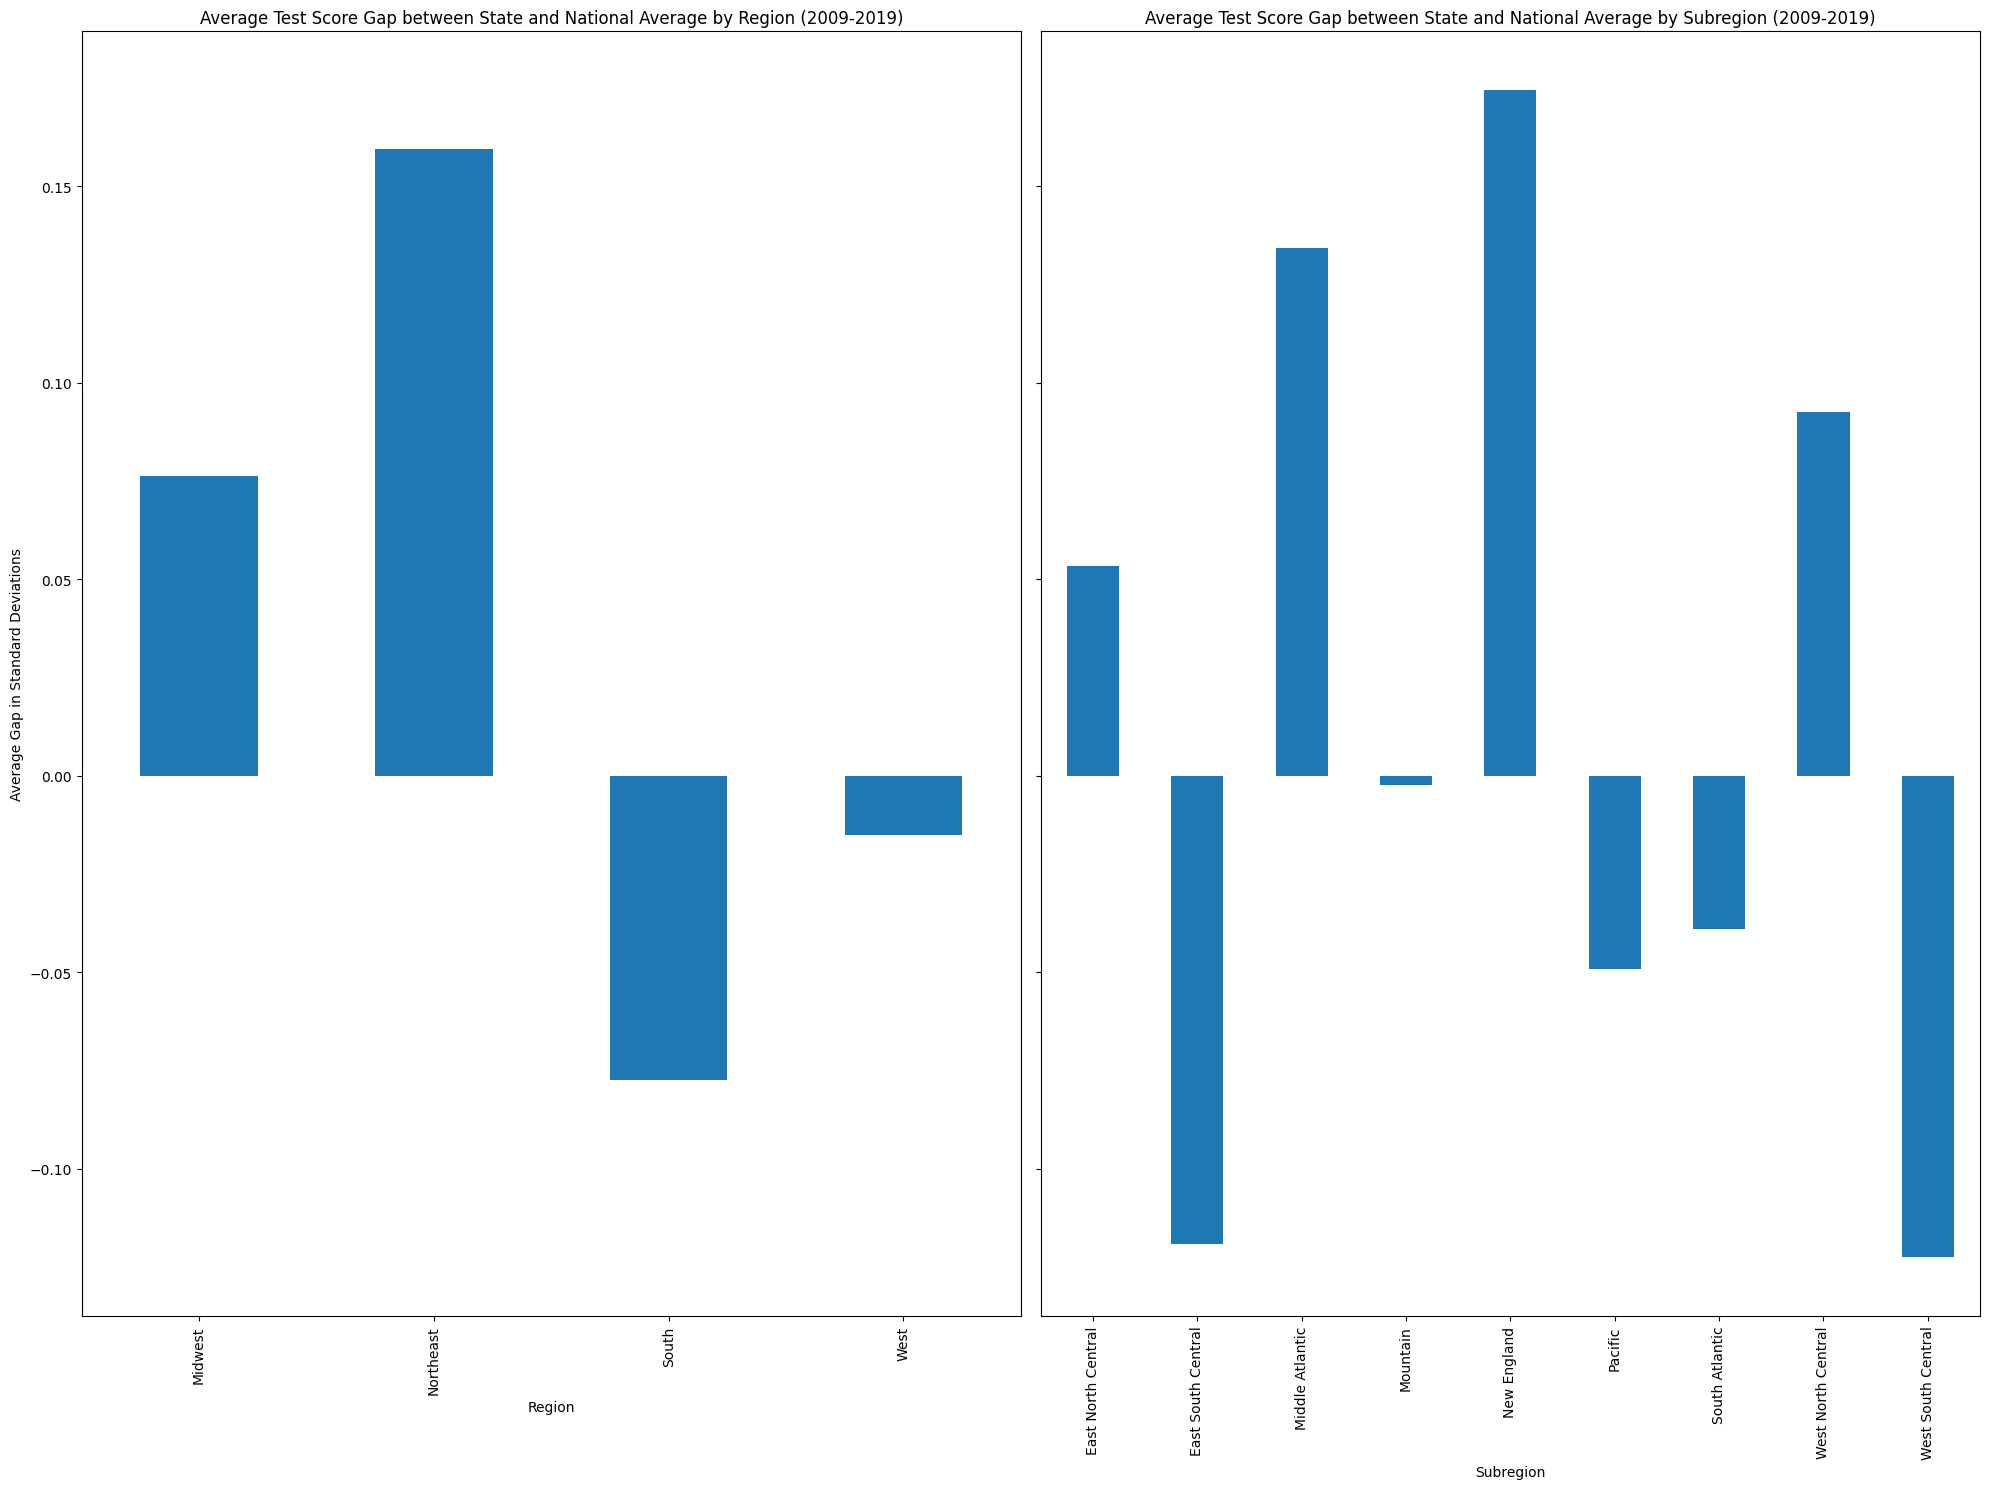

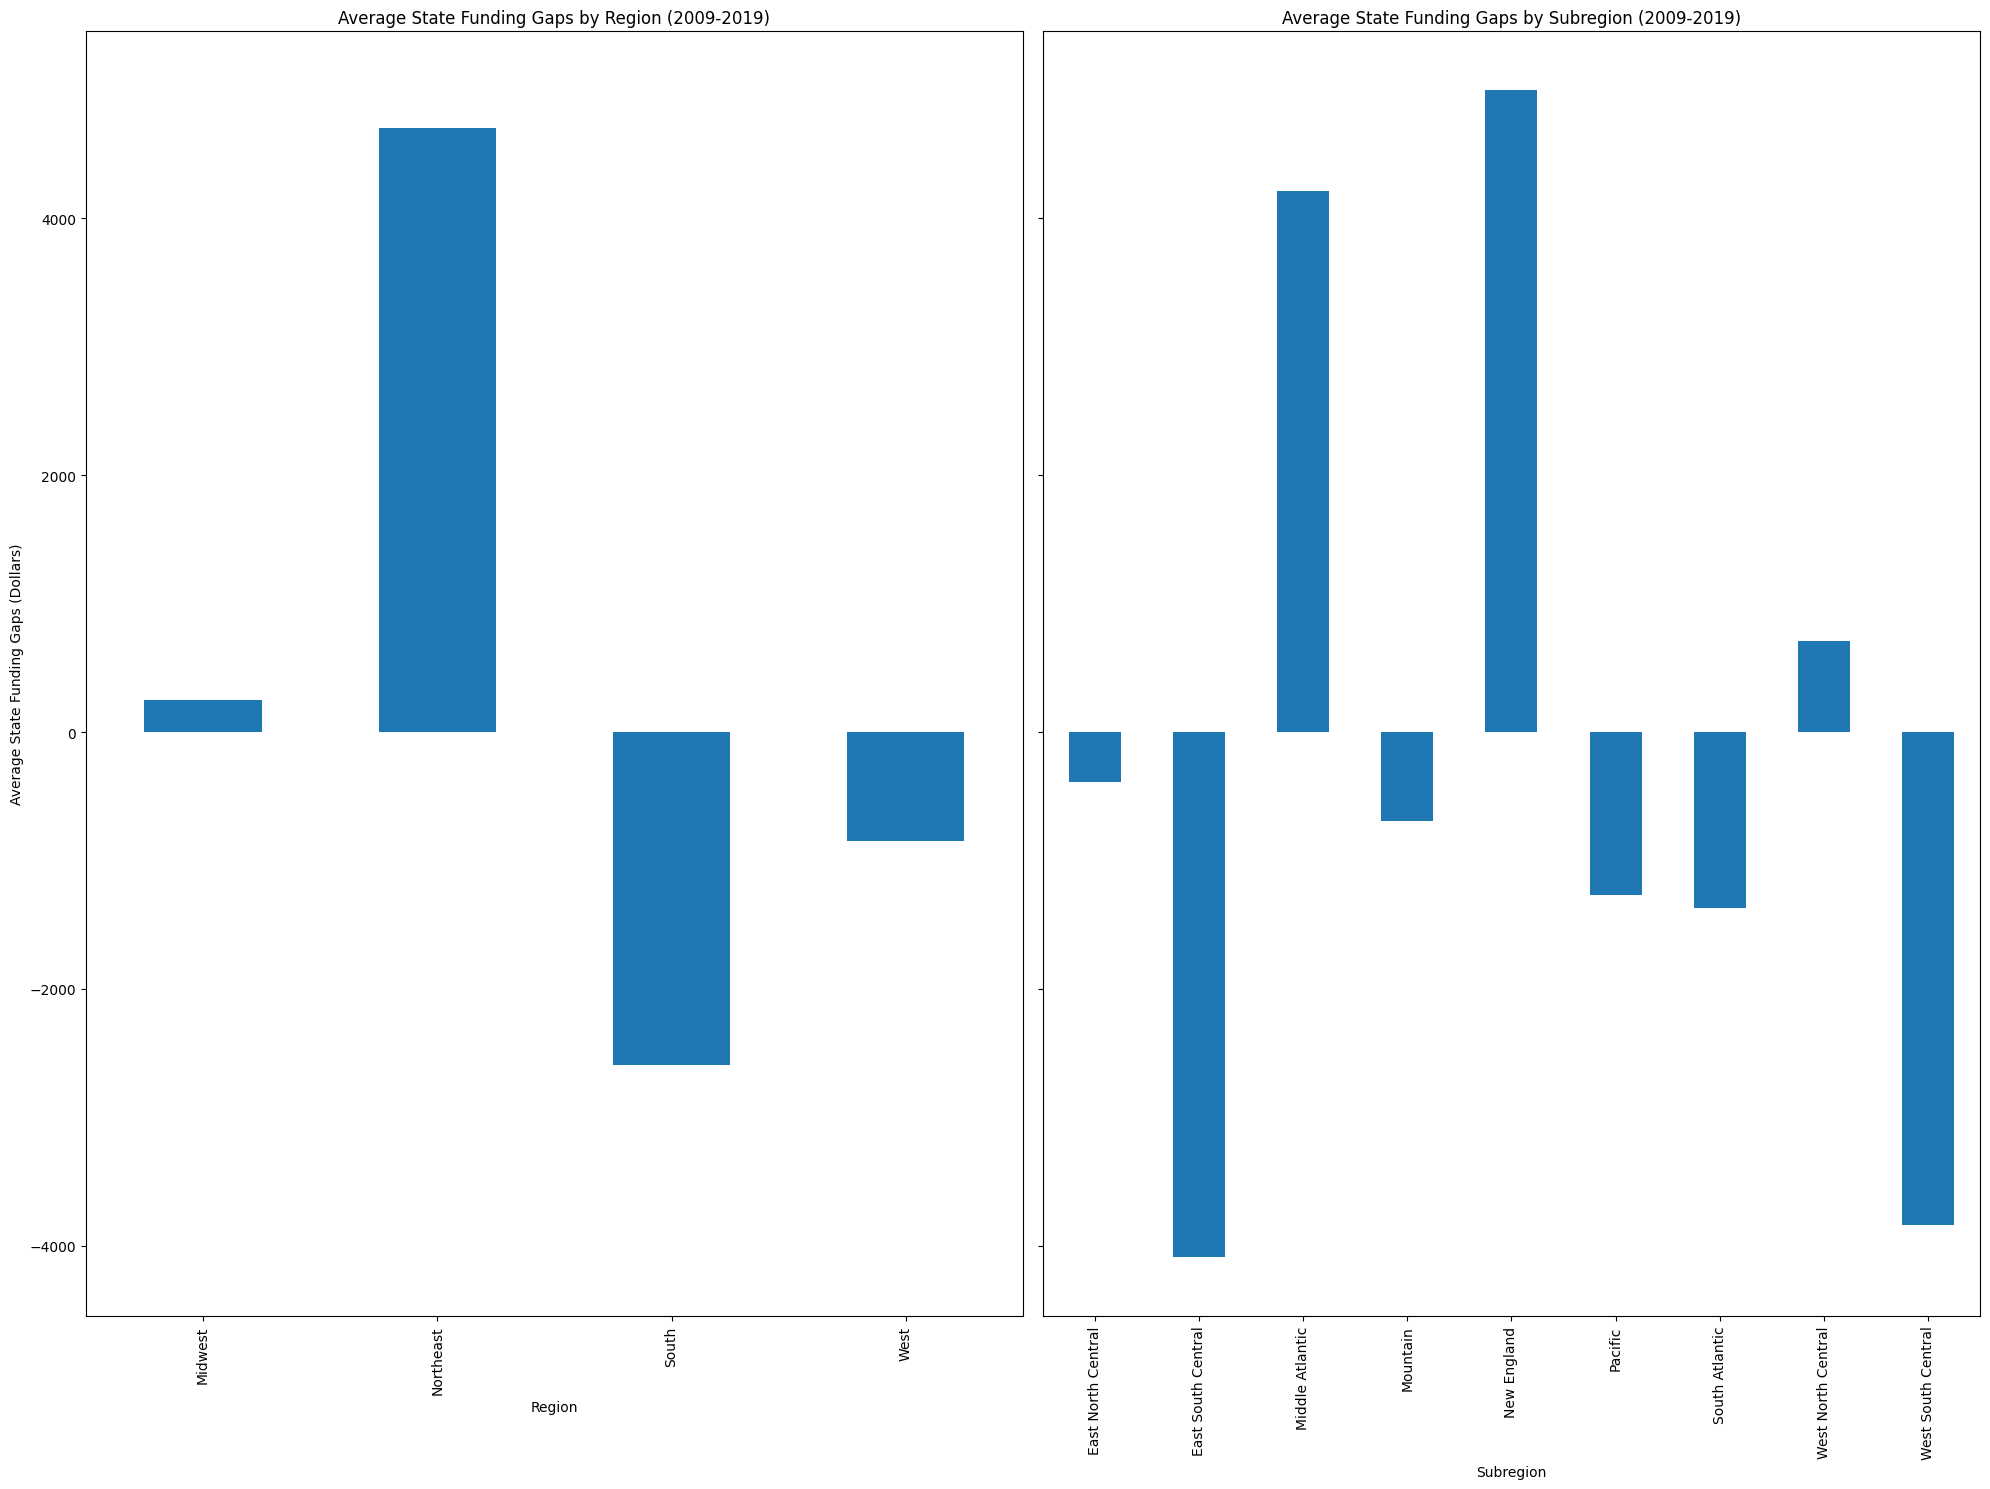

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

filtered_df.groupby("region4")[response_var].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Test Score Gap between State and National Average by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average Gap in Standard Deviations")

filtered_df.groupby("region9")[response_var].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Test Score Gap between State and National Average by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average Gap in Standard Deviations")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

filtered_df.groupby("region4")["necm_fundinggap_state"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average State Funding Gaps by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average State Funding Gaps (Dollars)")


filtered_df.groupby("region9")["necm_fundinggap_state"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average State Funding Gaps by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average State Funding Gap (Dollars)")
plt.tight_layout()
plt.show()

### Test Score Gap by State for years 2009 - 2019

##### Noteworthy Observations
* Test scores monotonically grow closer to the national average in Mississippi and the District of Columbia.
* New Hampshire consistently reports test scores above the national average, but test scores monotonically grow closer to the national average from 2013 - 2019.

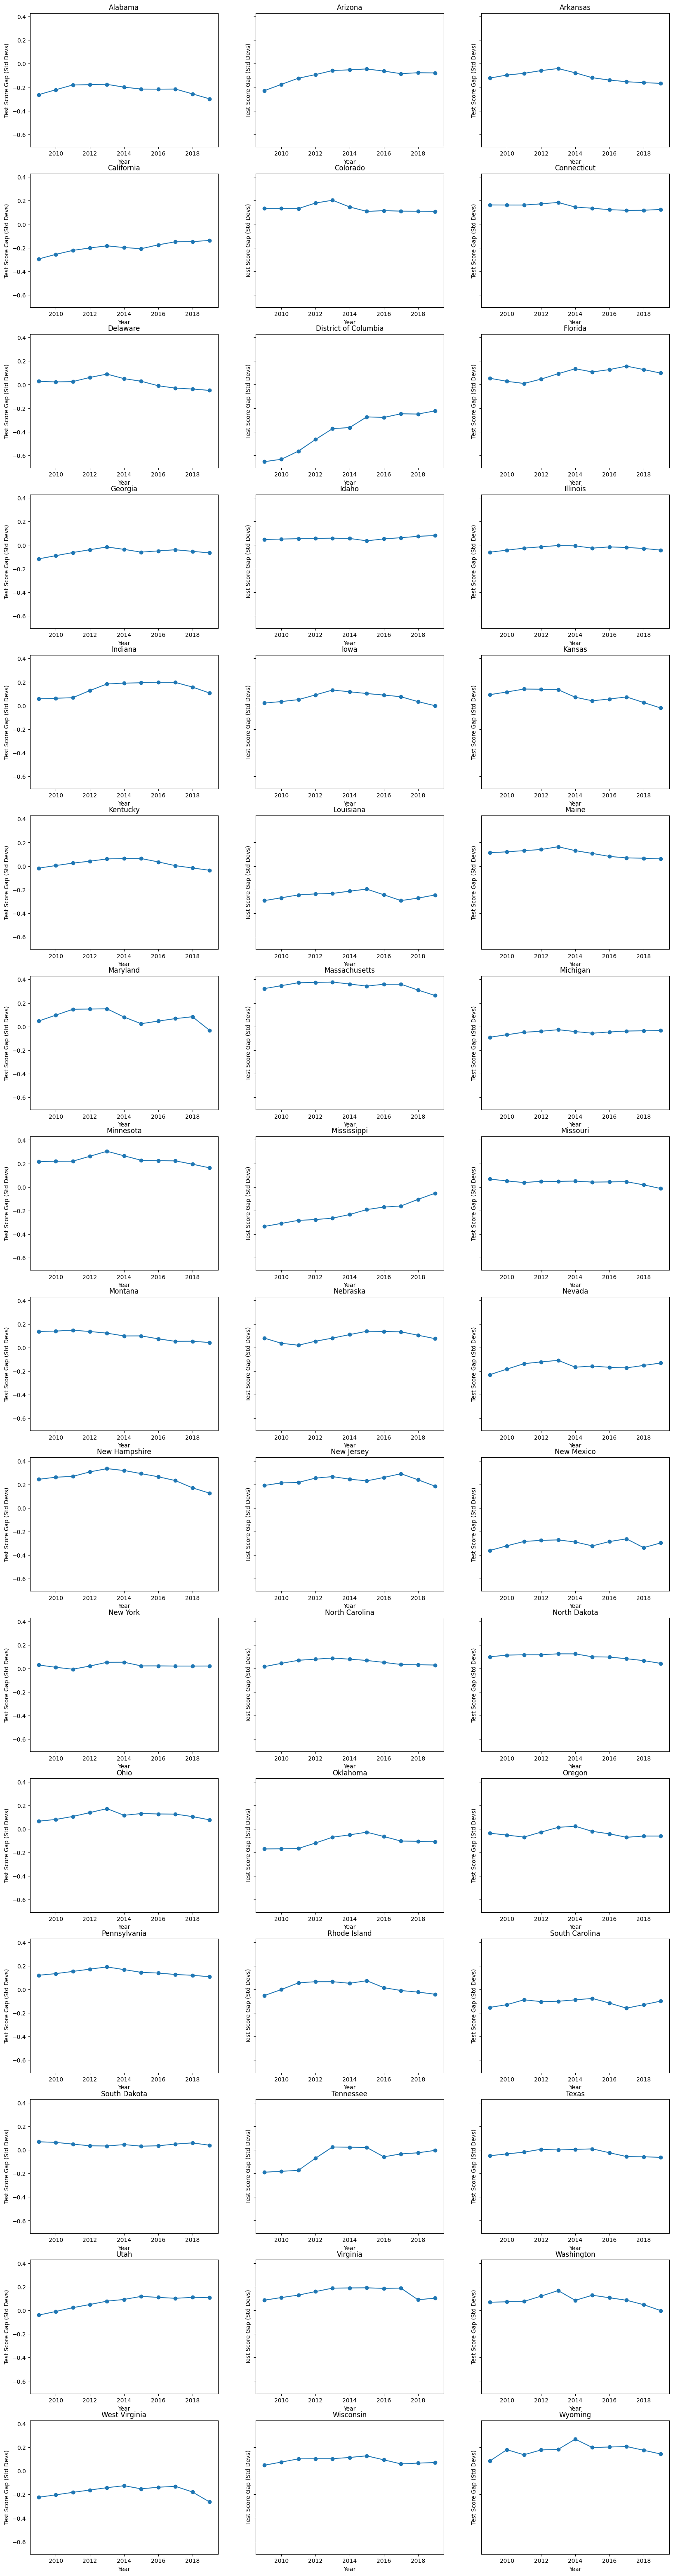

In [64]:
states = filtered_df["state_name"].unique()

fig, axes = plt.subplots(16, 3, figsize=(20, 80), sharey=True)

for state, ax in zip(states, axes.flatten()):
    state_data = filtered_df[filtered_df["state_name"] == state]
    ax.plot(state_data["year"], state_data[response_var], marker='o')
    ax.set_title(state)
    ax.set_xlabel("Year")
    ax.set_ylabel("Test Score Gap (Std Devs)")

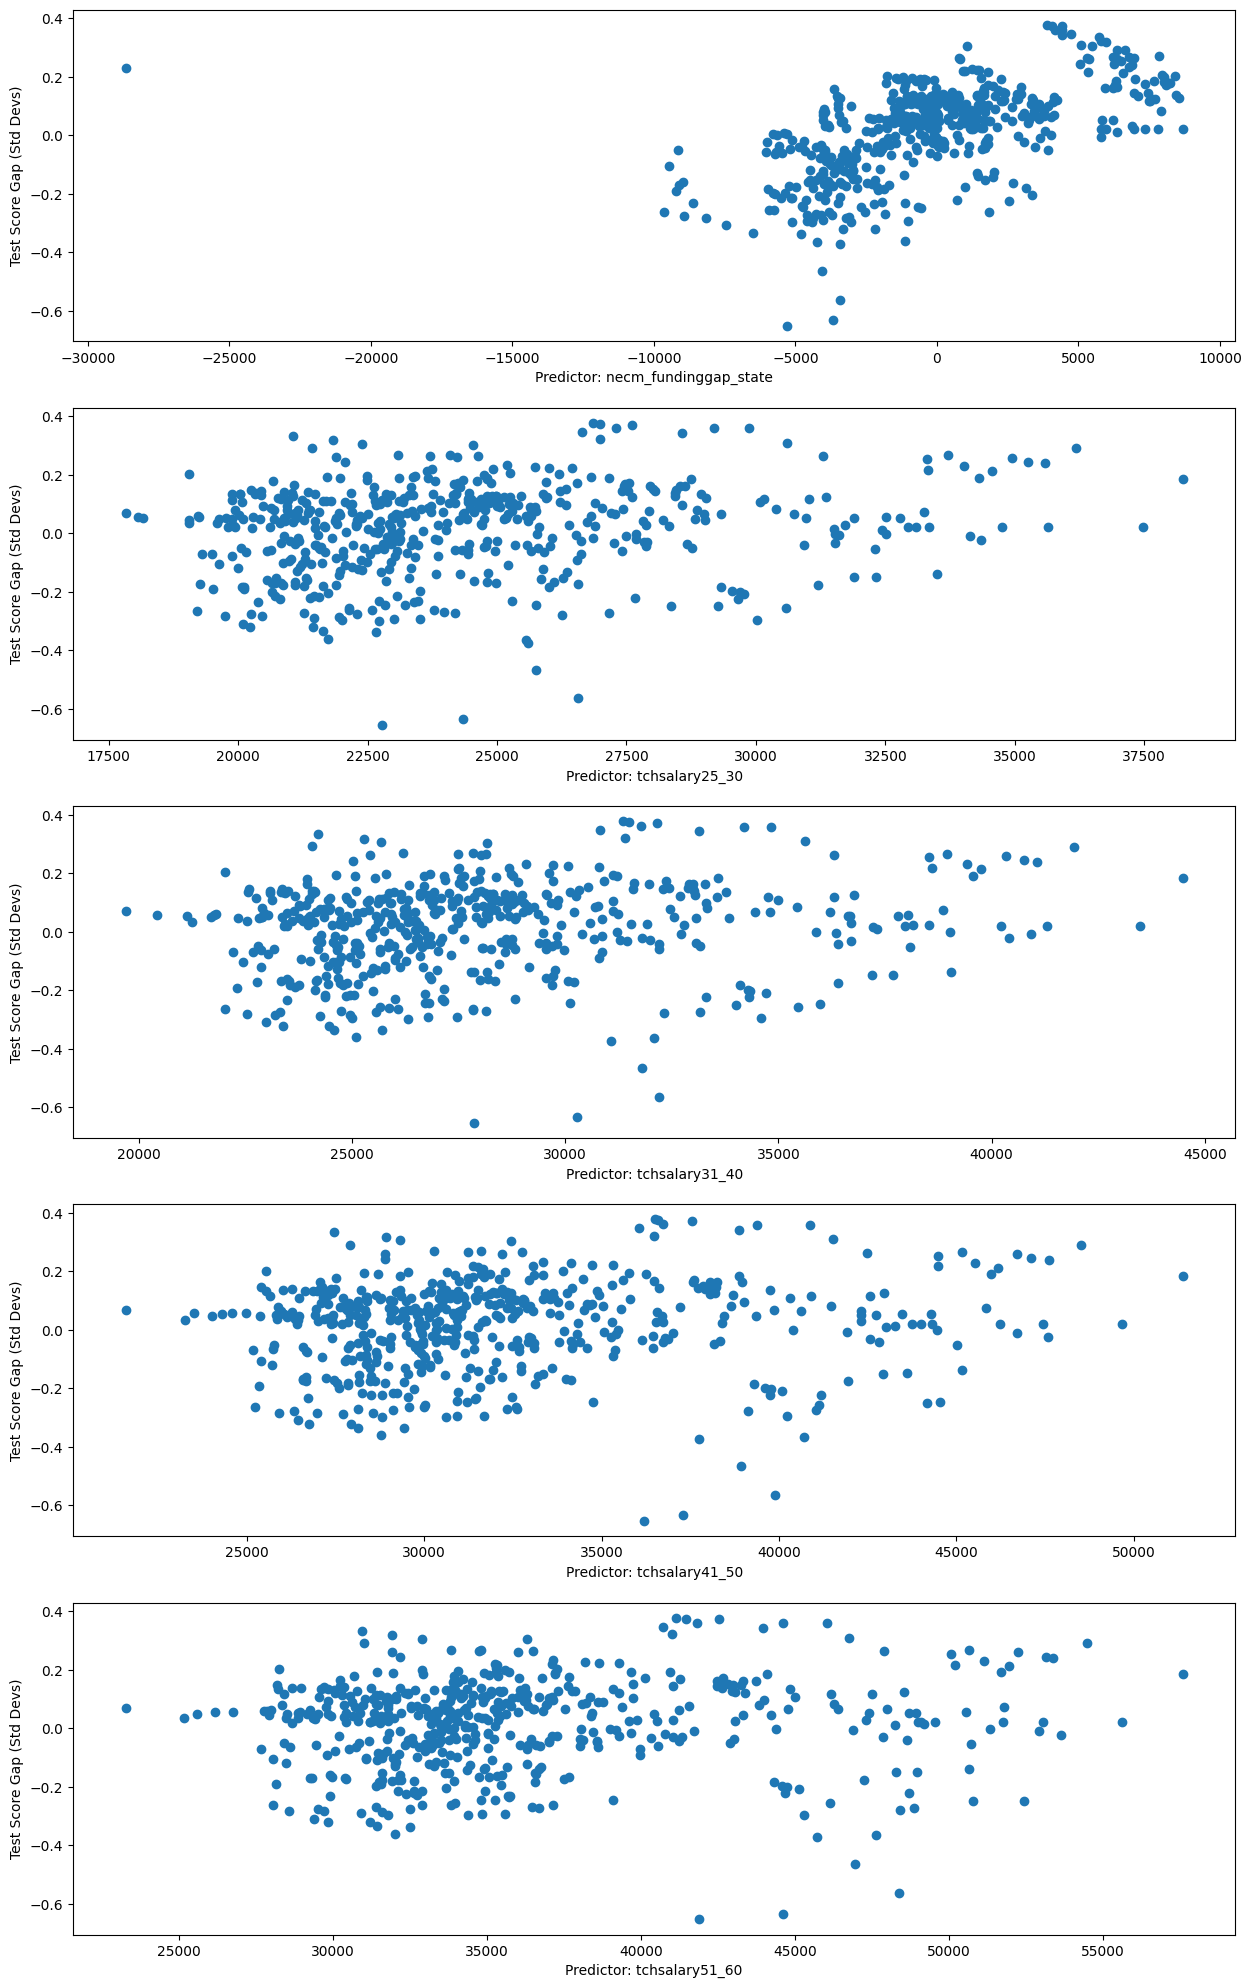

In [65]:
fig, axes = plt.subplots(5, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(predictors_of_interest[4:], axes.flatten()):
    ax.scatter(filtered_df[pred], filtered_df[response_var])
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Test Score Gap (Std Devs)")

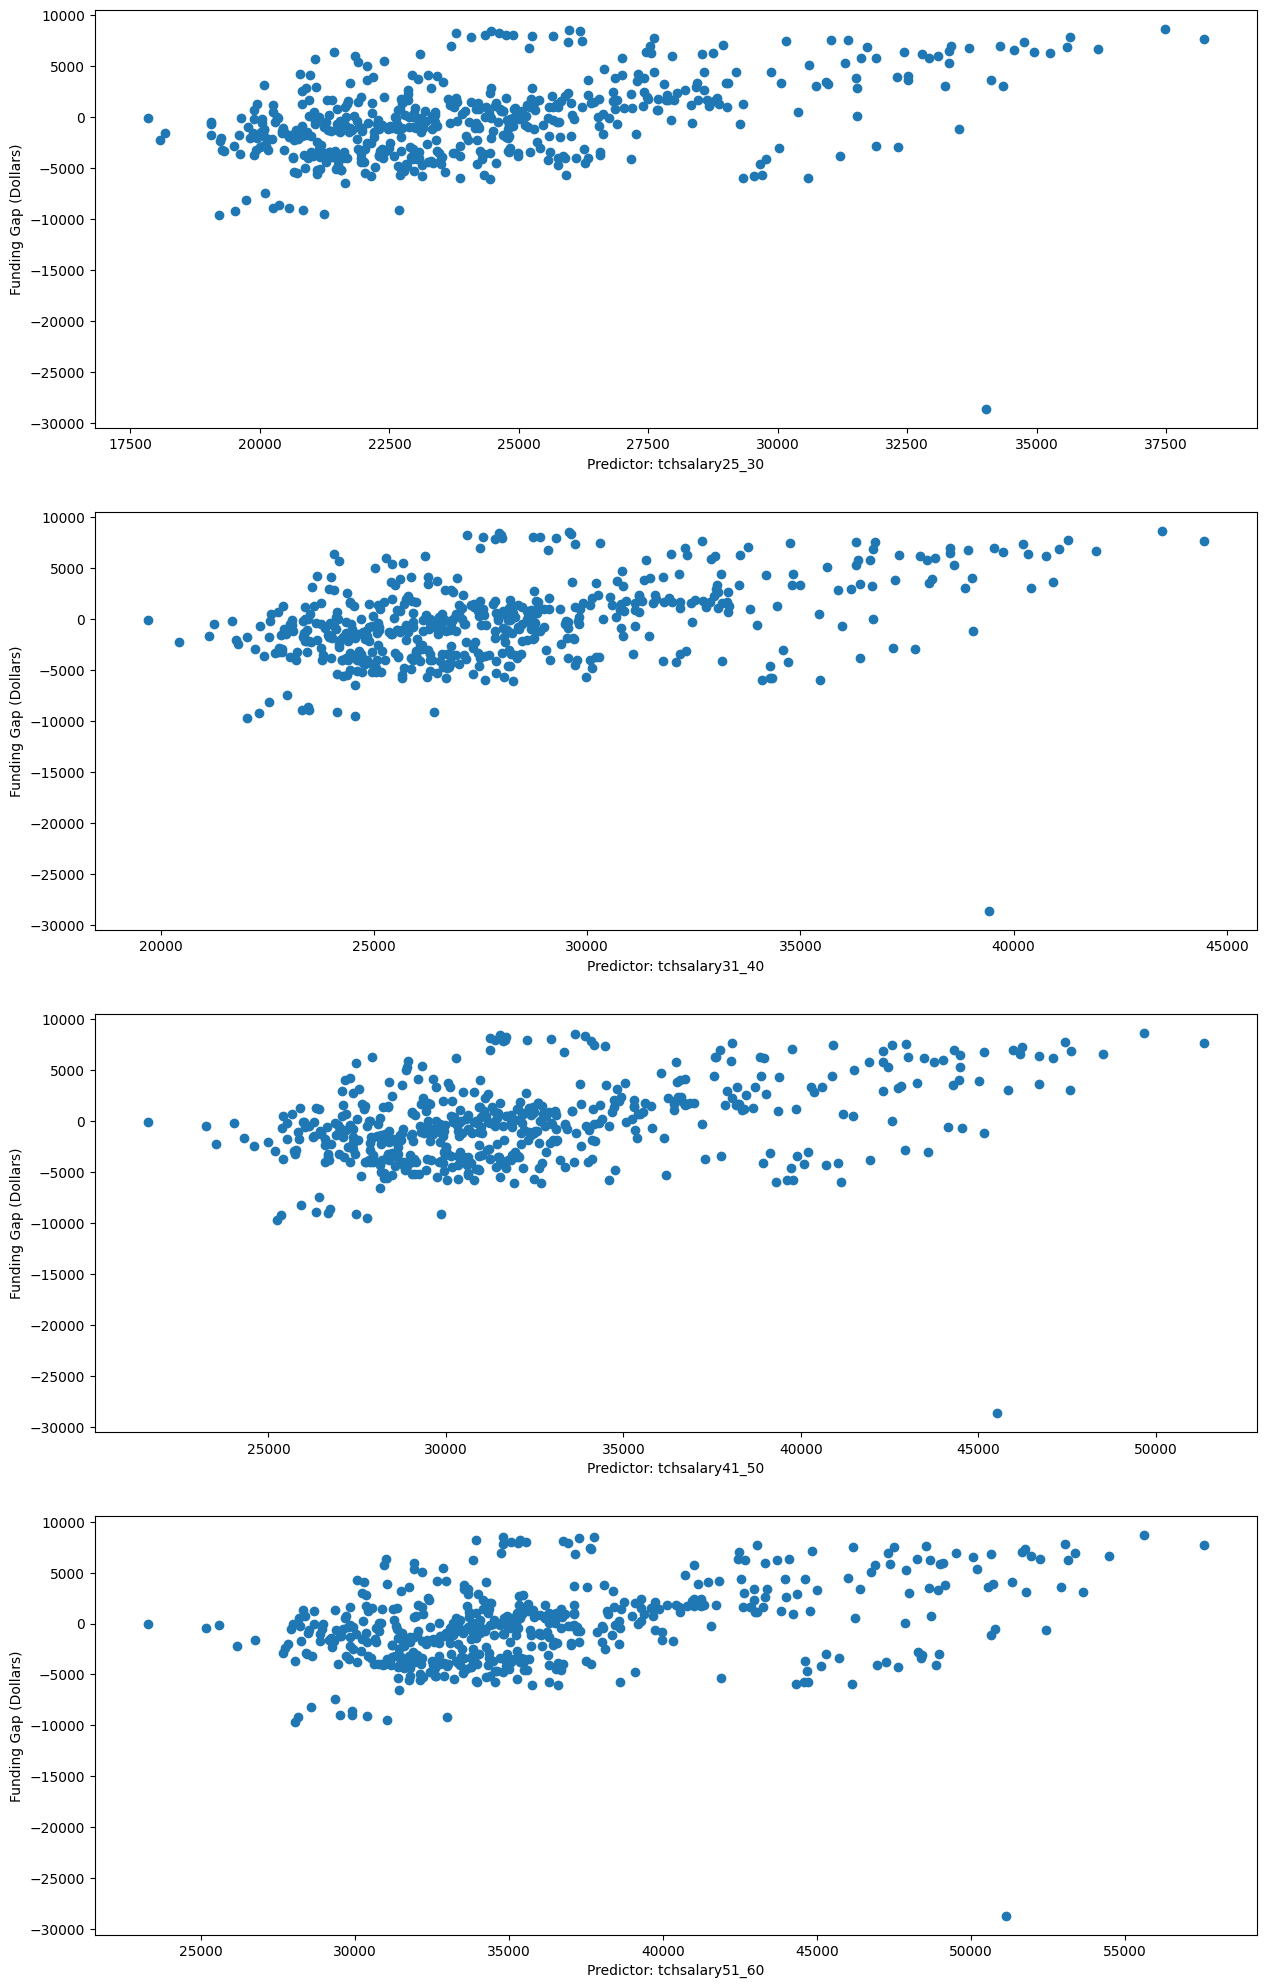

In [66]:
fig, axes = plt.subplots(4, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(predictors_of_interest[5:], axes.flatten()):
    ax.scatter(filtered_df[pred], filtered_df["necm_fundinggap_state"])
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Funding Gap (Dollars)")